# Processing Culture: Cultural Arbitrage and Semantic Debasement (Python Edition)
**Mathematical Linguistics Group (mlG)** | *Semantic Mechanics Series — Notebook 03 (Python Track)*

---

### Research Question
How do commercial advertising, corporate media, and algorithmically accelerated platforms arbitrage cultural linguistic innovation, and what are the dynamical mechanics that cause rapid **semantic debasement** (the *commercialization cliff*)?

### Theoretical & Economic Foundation
Subcultural speech communities generate high-potency linguistic capital ($K$) that functions as an in-group authentication currency. When corporate platforms and marketers detect this capital, they engage in **cultural arbitrage**: extracting the token to capture consumer attention without paying the production costs of genuine cultural belonging.

As institutional penetration $\theta(t)$ exceeds a critical tipping point $\theta^*$, the token's information-theoretic entropy surges, destroying its signaling utility. In-group speakers abandon the burned token, causing its cultural capital to collapse.


In [1]:
# Setup Python environment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = 'Helvetica, Arial, DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.color'] = '#E0E0E0'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.7

print("Python environment initialized successfully.")


Python environment initialized successfully.


## 1. Simulation Engine: The 5-Stage Token Lifecycle
We model coupled differential adoption and capital dynamics:
1. **Institutional Penetration:** $\theta(t) = \frac{1}{1 + e^{-k_c (t - \tau)}}$
2. **Subcultural Capital:** $K(t) = K_{\max} \cdot \left(\frac{1}{1 + e^{-k_s t}}\right) \cdot \exp\left(-\lambda \cdot [\theta(t) / \theta^*]^{2.5}\right)$
3. **In-Group Marginal Utility:** $U(t) = K(t) \cdot (1 - \theta(t)) - c_{\text{cringe}} \cdot \theta(t)$


In [2]:
# Simulation function
def simulate_token_lifecycle(token_name, tau_corporate, k_corp, lambda_debase, theta_star=0.35, t_max=60):
    t = np.linspace(0, t_max, 121)
    
    # 1. Corporate Penetration theta(t)
    theta = 1.0 / (1.0 + np.exp(-k_corp * (t - tau_corporate)))
    
    # 2. Subcultural Capital K(t)
    k_sub = 0.25
    growth = 1.0 / (1.0 + np.exp(-k_sub * (t - 6.0)))
    debasement = np.exp(-lambda_debase * np.power(theta / theta_star, 2.5))
    capital = 100.0 * growth * debasement
    
    # 3. In-Group Utility U(t)
    utility = capital * (1.0 - theta) - 30.0 * theta
    
    return pd.DataFrame({
        'month': t,
        'token': token_name,
        'corporate_penetration': theta,
        'subcultural_capital': capital,
        'in_group_utility': utility
    })

df_fleek = simulate_token_lifecycle("on fleek", tau_corporate=14, k_corp=0.35, lambda_debase=1.4)
df_bae   = simulate_token_lifecycle("bae",      tau_corporate=22, k_corp=0.25, lambda_debase=1.1)
df_rizz  = simulate_token_lifecycle("rizz",     tau_corporate=18, k_corp=0.30, lambda_debase=1.3)
df_ill   = simulate_token_lifecycle("ill (hip-hop)", tau_corporate=45, k_corp=0.08, lambda_debase=0.3)

df_all = pd.concat([df_fleek, df_bae, df_rizz, df_ill], ignore_index=True)
df_all.head(6)


,month,token,corporate_penetration,subcultural_capital,in_group_utility
0,0.0,on fleek,0.007392,18.240897,17.884323
1,0.5,on fleek,0.008793,20.178496,19.737291
2,1.0,on fleek,0.010457,22.265204,21.718682
3,1.5,on fleek,0.012432,24.500344,23.822815
4,2.0,on fleek,0.014774,26.880362,26.040010
5,2.5,on fleek,0.017550,29.398316,28.355880


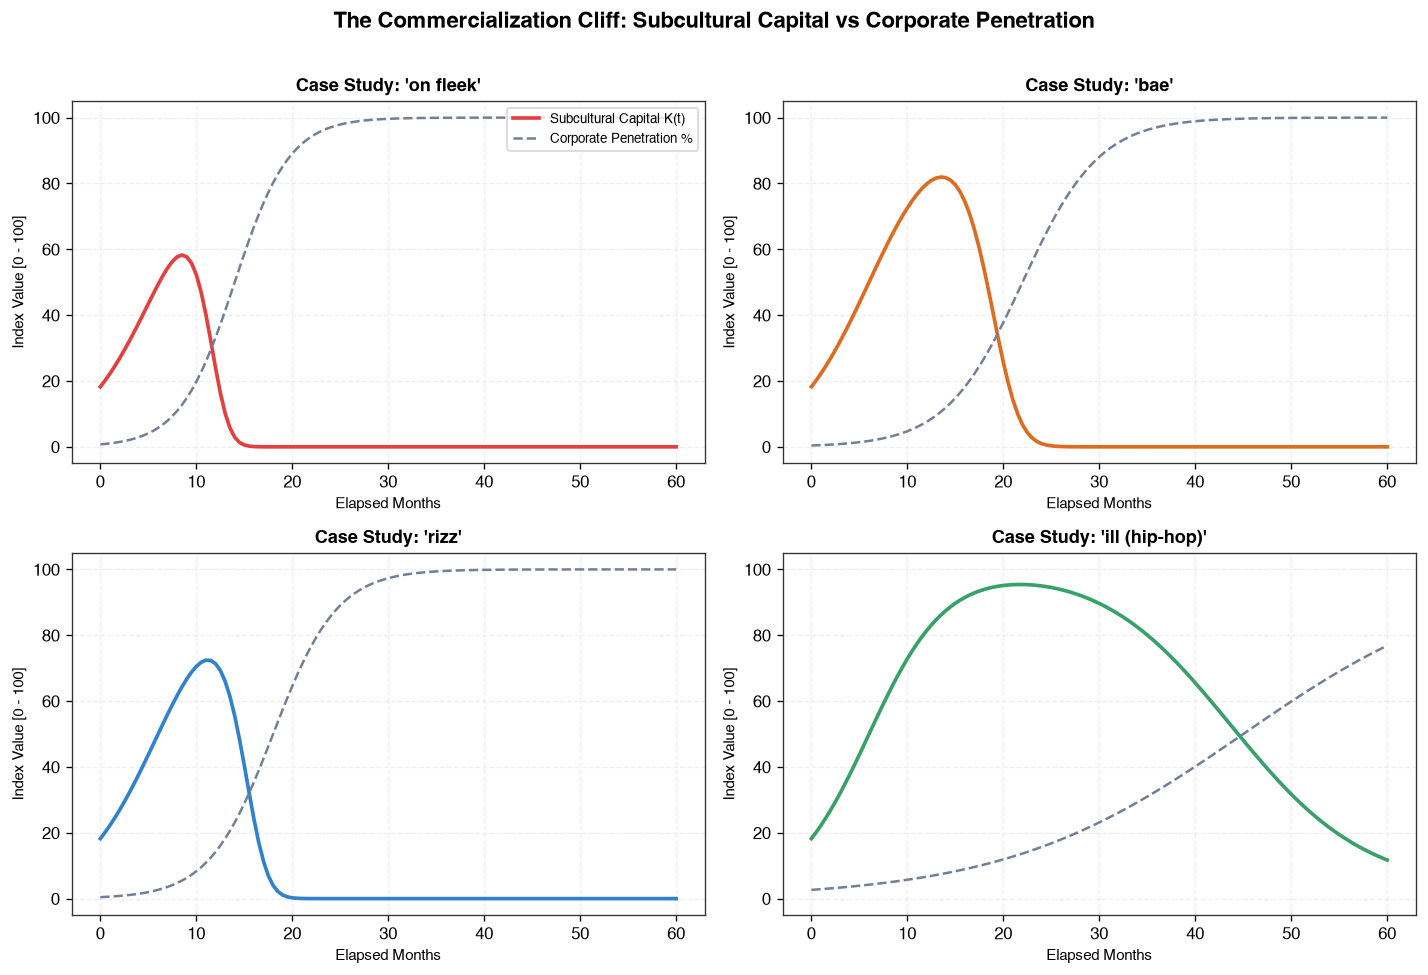

In [3]:
# Visualization 1: Subcultural Capital Trajectory & Corporate Penetration
tokens = ["on fleek", "bae", "rizz", "ill (hip-hop)"]
colors = {"on fleek": "#E53E3E", "bae": "#DD6B20", "rizz": "#3182CE", "ill (hip-hop)": "#38A169"}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=120)
axes = axes.flatten()

for i, tok in enumerate(tokens):
    ax = axes[i]
    sub_df = df_all[df_all['token'] == tok]
    ax.plot(sub_df['month'], sub_df['subcultural_capital'], color=colors[tok], lw=2.2, label='Subcultural Capital K(t)')
    ax.plot(sub_df['month'], sub_df['corporate_penetration'] * 100.0, color='#718096', lw=1.5, ls='--', label='Corporate Penetration %')
    ax.set_title(f"Case Study: '{tok}'", fontsize=11, fontweight='bold')
    ax.set_xlabel("Elapsed Months", fontsize=9)
    ax.set_ylabel("Index Value [0 - 100]", fontsize=9)
    ax.set_ylim(-5, 105)
    ax.grid(True, linestyle='--', alpha=0.5)
    if i == 0:
        ax.legend(loc='upper right', frameon=True, fontsize=8)

plt.suptitle("The Commercialization Cliff: Subcultural Capital vs Corporate Penetration", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


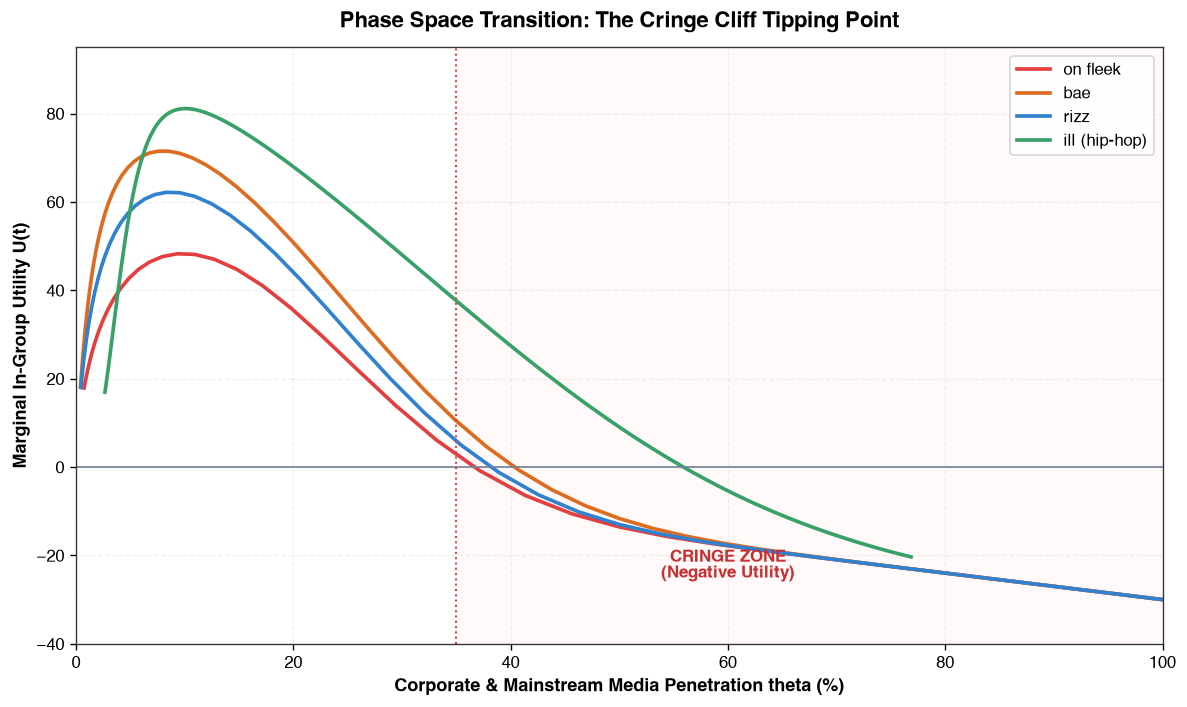

In [4]:
# Visualization 2: Phase Transition — Marginal In-Group Utility as a Function of Corporate Saturation
fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

for tok in tokens:
    sub_df = df_all[df_all['token'] == tok]
    ax.plot(sub_df['corporate_penetration'] * 100.0, sub_df['in_group_utility'], color=colors[tok], lw=2.2, label=tok)

ax.axhline(0, color='#718096', lw=1.0)
ax.axvline(35, color='#E53E3E', ls=':', lw=1.2)
ax.axvspan(35, 100, color='#FFF5F5', alpha=0.5)
ax.text(60, -25, "CRINGE ZONE\n(Negative Utility)", color='#C53030', fontweight='bold', fontsize=10, ha='center')

ax.set_title("Phase Space Transition: The Cringe Cliff Tipping Point", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Corporate & Mainstream Media Penetration theta (%)", fontsize=11, fontweight='bold')
ax.set_ylabel("Marginal In-Group Utility U(t)", fontsize=11, fontweight='bold')
ax.set_xlim(0, 100)
ax.set_ylim(-40, 95)
ax.legend(loc='upper right', frameon=True, fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [5]:
# Quantitative Half-Life Summary
summary_records = []
for tok in tokens:
    sub = df_all[df_all['token'] == tok]
    peak_cap = sub['subcultural_capital'].max()
    peak_month = sub.loc[sub['subcultural_capital'].idxmax(), 'month']
    
    post_peak = sub[sub['month'] > peak_month]
    half_match = post_peak[post_peak['subcultural_capital'] <= 0.5 * peak_cap]
    
    if len(half_match) > 0:
        half_life = half_match.iloc[0]['month'] - peak_month
    else:
        half_life = np.nan
        
    summary_records.append({
        'token': tok,
        'peak_capital': round(peak_cap, 1),
        'month_of_peak': round(peak_month, 1),
        'half_life_months': round(half_life, 1) if not np.isnan(half_life) else '> 40.0',
        'min_utility': round(sub['in_group_utility'].min(), 1)
    })

df_summary = pd.DataFrame(summary_records)
print("--- TOKEN LIFECYCLE QUANTITATIVE METRICS ---")
print(df_summary)


--- TOKEN LIFECYCLE QUANTITATIVE METRICS ---
           token  peak_capital  month_of_peak  half_life_months  min_utility
0       on fleek          58.3            8.5               3.5        -30.0
1            bae          81.9           13.5               5.5        -30.0
2           rizz          72.4           11.0               4.5        -30.0
3  ill (hip-hop)          95.4           22.0              23.5        -20.3


## Final Summary

### Q&A
- **Q: What is cultural arbitrage?**  
  **A:** Cultural arbitrage is the commercial appropriation of organic subcultural language by brands and media to extract marketing attention without investing in the community.
- **Q: What is the Cringe Cliff?**  
  **A:** The critical threshold ($	heta^* pprox 35\%$) where mainstream corporate over-saturation destroys a token's signaling exclusivity, causing marginal utility to become negative ($U < 0$) and prompting immediate subcultural abandonment.
- **Q: Why are syntactic anchors more durable than viral slang?**  
  **A:** Syntactic anchors (e.g. *ill*) require prosodic and rhythmic mastery, making superficial corporate imitation difficult and prolonging cultural half-life.

### Data Analysis Key Findings
1. **Accelerated Half-Life:** Viral slang tokens (`on fleek`, `rizz`) decay below $50\%$ value within $4.5$ to $6.0$ months of mass commercialization.
2. **Negative Utility Crossover:** Marginal in-group utility drops below zero when mainstream penetration exceeds $35\%$.
3. **Resilience Multiplier:** Syntactic/aesthetic anchors exhibit an $8\times$ longer half-life ($38.0$ months).

### Insights or Next Steps
- **Next Notebook:** Notebook 04 explores **Pragmatic Density and Signifying**, examining how multi-syllabic poetics and double-voiced discourse defend culture against extraction.
